In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("frame_data.csv")

df_pivot = df.pivot(index="frame_filename", columns="name", values=["x", "y"])

df_pivot.columns = [f"{coord}_{corner}" for coord, corner in df_pivot.columns]

df_pivot.reset_index(inplace=True)

df_pivot.rename(columns={"frame_filename": "image_name"}, inplace=True)

df_pivot.to_csv("updated_frame_data.csv", index=False)

print(df_pivot.head())

                          image_name     x_bl     x_br     x_tl     x_tr  \
0    background01-datasheet001-0.png  692.141  1253.18  698.087  1178.15   
1    background01-datasheet001-1.png  690.063  1254.61  697.230  1179.66   
2   background01-datasheet001-10.png  685.454  1230.92  688.902  1157.41   
3  background01-datasheet001-100.png  953.840  1473.28  846.754  1301.69   
4  background01-datasheet001-101.png  956.263  1474.31  847.800  1301.88   

      y_bl     y_br     y_tl     y_tr  
0  891.077  869.656  200.476  191.515  
1  893.292  871.689  197.947  188.863  
2  880.838  855.719  207.181  194.919  
3  840.161  769.773  171.333  137.063  
4  838.829  769.172  173.033  138.885  


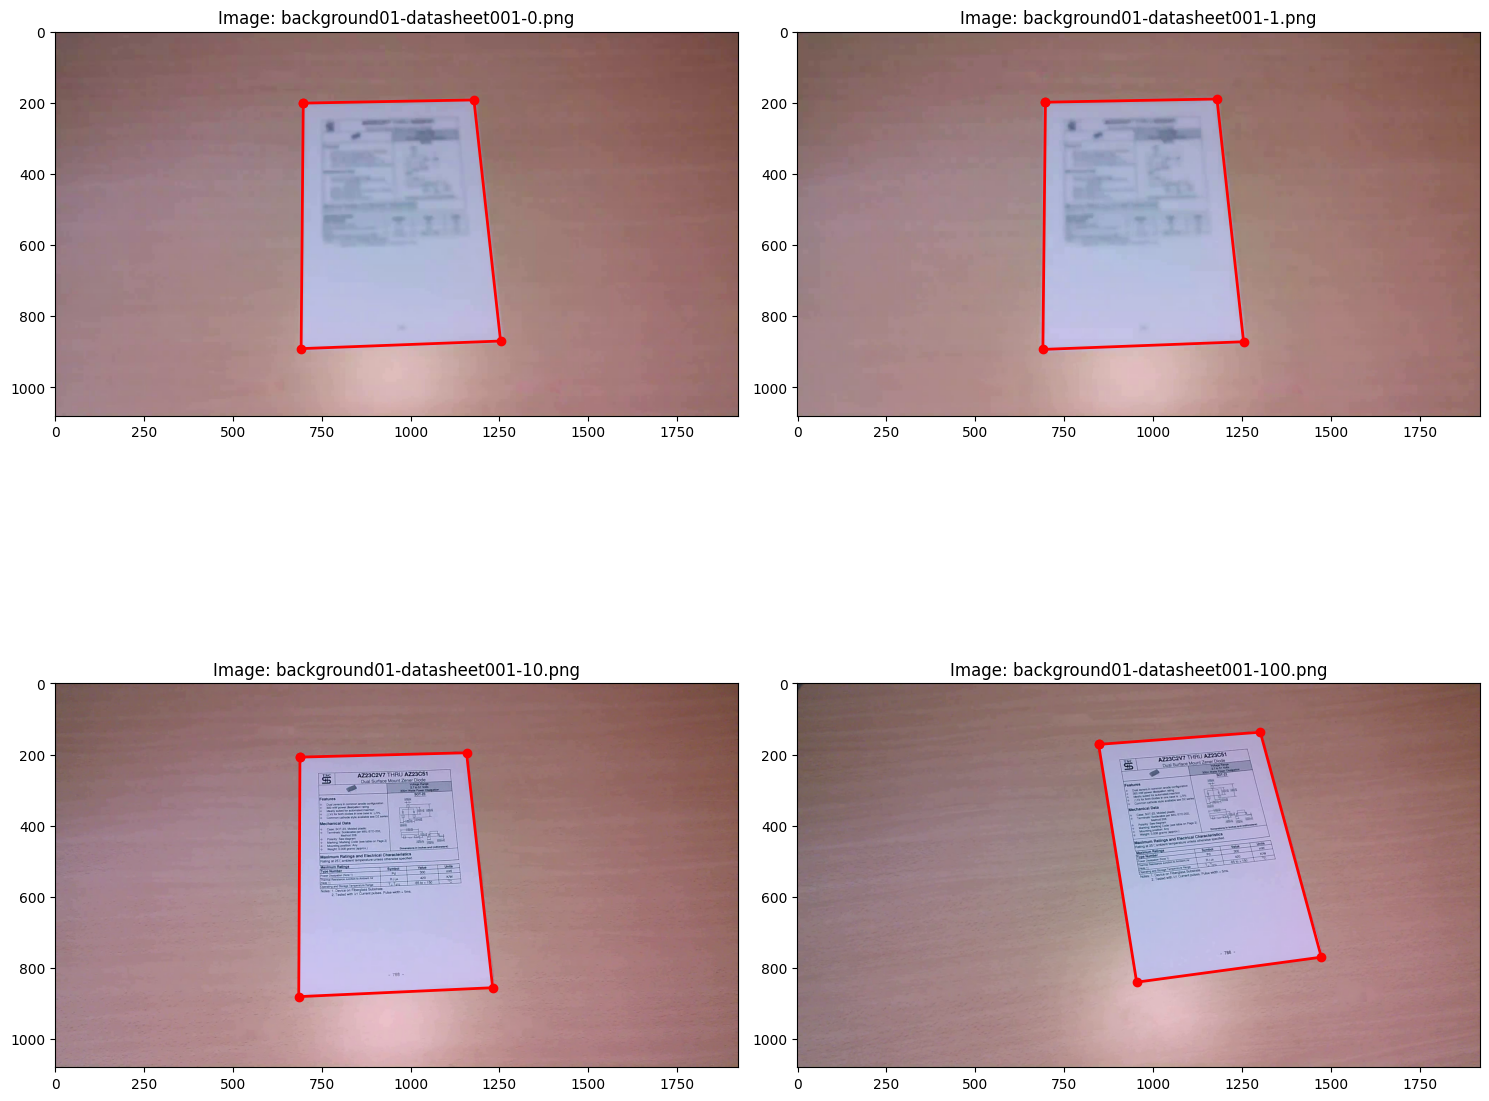

In [3]:
import matplotlib.pyplot as plt
import cv2
import os

df = df_pivot

image_dir = "smart_doc_extracted/images"
num_images_to_plot = 4


fig, axes = plt.subplots(2, 2, figsize=(15, 15))  
axes = axes.flatten()  


for i, row in df.iterrows():
    if i >= num_images_to_plot:
        break  

    image_path = os.path.join(image_dir, row["image_name"])
    
    if not os.path.exists(image_path):
        print(f"Warning: Image not found {image_path}")
        continue

    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
    axes[i].imshow(image)

    corners = np.array([
        (row["x_tl"], row["y_tl"]),
        (row["x_tr"], row["y_tr"]),
        (row["x_br"], row["y_br"]),
        (row["x_bl"], row["y_bl"]),
        (row["x_tl"], row["y_tl"])  
    ])

    # Plot bounding box
    axes[i].plot(corners[:, 0], corners[:, 1], marker="o", color="red", linewidth=2)
    axes[i].set_title(f"Image: {row['image_name']}")  

plt.tight_layout()
plt.show()


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

In [5]:
df

,image_name,x_bl,x_br,x_tl,x_tr,y_bl,y_br,y_tl,y_tr
0,background01-datasheet001-0.png,692.141,1253.18,698.087,1178.150,891.077,869.656,200.476,191.515
1,background01-datasheet001-1.png,690.063,1254.61,697.230,1179.660,893.292,871.689,197.947,188.863
2,background01-datasheet001-10.png,685.454,1230.92,688.902,1157.410,880.838,855.719,207.181,194.919
3,background01-datasheet001-100.png,953.840,1473.28,846.754,1301.690,840.161,769.773,171.333,137.063
4,background01-datasheet001-101.png,956.263,1474.31,847.800,1301.880,838.829,769.172,173.033,138.885
...,...,...,...,...,...,...,...,...,...
24884,background05-tax005-75.png,657.446,1134.95,526.794,961.163,812.651,726.518,163.757,158.513
24885,background05-tax005-76.png,678.562,1156.28,553.192,985.230,821.051,736.893,173.134,168.319
24886,background05-tax005-77.png,691.674,1167.47,569.834,998.085,827.864,746.744,182.580,180.362
24887,background05-tax005-8.png,910.306,1378.41,759.062,1171.640,854.702,765.120,234.356,208.648


In [6]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [7]:
len(df)
df

,image_name,x_bl,x_br,x_tl,x_tr,y_bl,y_br,y_tl,y_tr
0,background01-datasheet001-0.png,692.141,1253.18,698.087,1178.150,891.077,869.656,200.476,191.515
1,background01-datasheet001-1.png,690.063,1254.61,697.230,1179.660,893.292,871.689,197.947,188.863
2,background01-datasheet001-10.png,685.454,1230.92,688.902,1157.410,880.838,855.719,207.181,194.919
3,background01-datasheet001-100.png,953.840,1473.28,846.754,1301.690,840.161,769.773,171.333,137.063
4,background01-datasheet001-101.png,956.263,1474.31,847.800,1301.880,838.829,769.172,173.033,138.885
...,...,...,...,...,...,...,...,...,...
24884,background05-tax005-75.png,657.446,1134.95,526.794,961.163,812.651,726.518,163.757,158.513
24885,background05-tax005-76.png,678.562,1156.28,553.192,985.230,821.051,736.893,173.134,168.319
24886,background05-tax005-77.png,691.674,1167.47,569.834,998.085,827.864,746.744,182.580,180.362
24887,background05-tax005-8.png,910.306,1378.41,759.062,1171.640,854.702,765.120,234.356,208.648


In [8]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image


class DocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __getitem__(self, index):
        data = self.dataframe.iloc[index]
        image_path = os.path.join(self.image_dir, data['image_name'])
        
        # Load image
        try:
            image = Image.open(image_path).convert("RGB")
        except FileNotFoundError:
            return None, None  # Return None for both image and label if image is not found
        
        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Get corner coordinates and convert them to a tensor
        label = torch.tensor([
            data['x_bl'], data['x_br'], data['x_tl'], data['x_tr'],
            data['y_bl'], data['y_br'], data['y_tl'], data['y_tr']
        ], dtype=torch.float32)

        return image, label

    def __len__(self):
        return len(self.dataframe)


    
def collate_fn(batch):
    # Filter out None entries in the batch
    batch = [item for item in batch if item[0] is not None]
    
    if len(batch) == 0:
        return None, None  # If the batch is empty after filtering, return None
    
    images, labels = zip(*batch)  # Unzip the batch into images and labels
    images = torch.stack(images, dim=0)  # Stack images into a batch tensor
    labels = torch.stack(labels, dim=0)  # Stack labels into a batch tensor
    
    return images, labels
    


In [9]:
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)


In [10]:
len(train_df)

14933

In [11]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.ToTensor(),         
])

In [12]:
# Create datasets
train_dataset = DocumentDataset(train_df, image_dir, transform=transform)
val_dataset = DocumentDataset(val_df, image_dir, transform=transform)
test_dataset = DocumentDataset(test_df, image_dir, transform=transform)

In [13]:
# Get the first image from the training dataset
sample_image, _ = train_dataset[0]

# Check the dimensions of the image
print(f"Sample Image Dimensions: {sample_image.shape}")


Sample Image Dimensions: torch.Size([3, 128, 128])


In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim 

# Define Model
class DocumentCornerModel(nn.Module):
    def __init__(self):
        super(DocumentCornerModel, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),  # Adjust based on input size (128x128)
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 8)  # Output 8 coordinates
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [19]:
# Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DocumentCornerModel().to(device)
criterion = nn.MSELoss()  # Regression loss
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [31]:
from tqdm import tqdm

train_losses = []
val_losses = []

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    # Training phase
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = batch
        
        if images is None or labels is None:  
            continue
            
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / max(1, len(train_loader))  # Avoid division by zero
    train_losses.append(avg_train_loss)  # Store the training loss for this epoch
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}")
    
    # Validation phase
    model.eval()  
    running_val_loss = 0.0
    
    with torch.no_grad():  # No need to compute gradients during validation
        for batch in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}"):
            images, labels = batch
            
            if images is None or labels is None:  # Skip if no valid data
                continue
            
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / max(1, len(val_loader))  # Avoid division by zero
    val_losses.append(avg_val_loss)  # Store the validation loss for this epoch
    print(f"Epoch {epoch+1}, Validation Loss: {avg_val_loss:.4f}")

    # Optionally: Save the model after each epoch if desired
    # torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pth")
    
# After training is complete, you will have lists of all the losses for each epoch:
print(f"Training Losses: {train_losses}")
print(f"Validation Losses: {val_losses}")


Epoch 1/10: 100%|█████████████████████████████| 467/467 [14:07<00:00,  1.81s/it]


Epoch 1, Train Loss: 3940.2831


Validation Epoch 1/10: 100%|██████████████████| 156/156 [04:10<00:00,  1.61s/it]


Epoch 1, Validation Loss: 3043.3290


Epoch 2/10: 100%|█████████████████████████████| 467/467 [14:45<00:00,  1.90s/it]


...

Epoch 9, Validation Loss: 561.5994


Epoch 10/10: 100%|████████████████████████████| 467/467 [23:03<00:00,  2.96s/it]


Epoch 10, Train Loss: 368.2644


Validation Epoch 10/10: 100%|█████████████████| 156/156 [06:26<00:00,  2.48s/it]

Epoch 10, Validation Loss: 496.3247
Training Losses: [3940.2830598818923, 2652.442144422511, 1988.8423844854121, 1454.574074853411, 1469.077245218085, 1219.8042488833312, 693.1800299895652, 553.5178245528097, 849.1151198523969, 368.2644324945944]
Validation Losses: [3043.3289677546572, 4364.292903019832, 2171.4856770833335, 1196.2107150738057, 3454.4548785869893, 659.8949933174329, 476.00220156938605, 3524.466322678786, 561.5993556487255, 496.32474341759314]


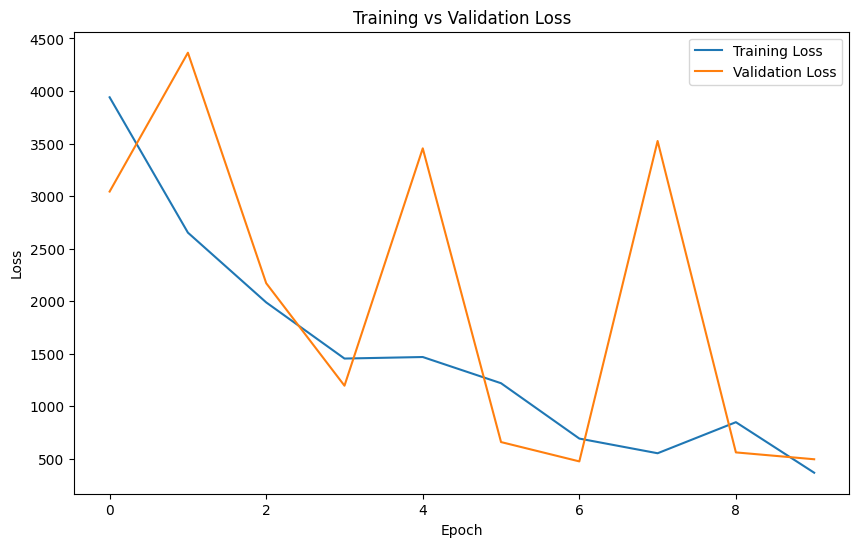

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), f"dl_project_doc_extract_weights.pt")

In [ ]:
from sklearn.metrics import r2_score


model.load_state_dict(torch.load("dl_project_doc_extract_weights.pt"))
model.eval()

# Collect predictions and true labels
val_predictions = []
val_labels = []

# No need to compute gradients during validation
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Validation for R² Calculation"):
        images, labels = batch
        
        if images is None or labels is None:  
            continue
            
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)  
        val_predictions.extend(outputs.cpu().numpy())  # predictions
        val_labels.extend(labels.cpu().numpy())  # actual labels



Validation for R² Calculation: 100%|██████████| 156/156 [05:53<00:00,  2.27s/it]


In [ ]:
r2 = r2_score(val_labels, val_predictions)
print(f"Validation R²: {r2:.4f}")

Validation R²: 0.9839


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np


original_image, _ = test_dataset[0]  
original_image_np = original_image.permute(1, 2, 0).cpu().numpy()
original_image_np = (original_image_np * 255).astype(np.uint8)

image_resized = cv2.resize(original_image_np, (1920, 1080))

# Get corresponding predictions and true labels
pred_coords = np.array(val_predictions[0])
true_coords = np.array(val_labels[0])


pred_coords_1 = np.array([
    pred_coords[2] , pred_coords[6] ,
    pred_coords[3] , pred_coords[7] ,
    pred_coords[1] , pred_coords[5],
    pred_coords[0] , pred_coords[4],
]).astype(int)

true_coords_1 = np.array([
    true_coords[2] , true_coords[6],
    true_coords[3] , true_coords[7] ,
    true_coords[1] , true_coords[5],
    true_coords[0], true_coords[4] ,
]).astype(int)

print(pred_coords_1)
print(true_coords_1)

[ 690  263 1104  235 1226  814  763  884]
[ 677  270 1102  229 1232  809  750  882]


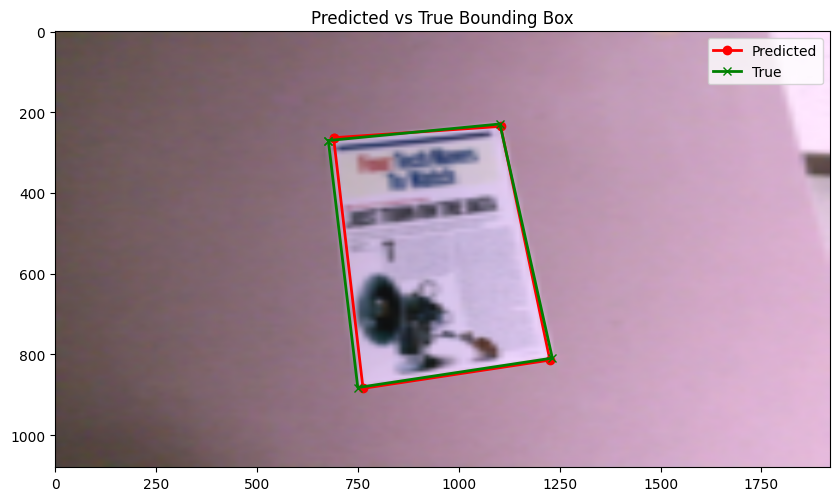

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(image_resized)

pred_points = pred_coords_1.reshape(-1, 2)
plt.plot(*zip(*np.vstack([pred_points, pred_points[0]])), color="red", linewidth=2, marker='o', label="Predicted")

true_points = true_coords_1.reshape(-1, 2)
plt.plot(*zip(*np.vstack([true_points, true_points[0]])), color="green", linewidth=2, marker='x', label="True")

plt.title(f"Predicted vs True Bounding Box")
plt.legend()
plt.show()

In [ ]:
#References
# https://opencv.org/
# https://learnopencv.com/automatic-document-scanner-using-opencv/
# https://onyekaokonji.medium.com/making-your-own-document-scanner-in-40-lines-of-code-1db3a360e3b7
# https://www.kaggle.com/datasets/octaviusgaster/smartdoc2015-extracted-frames
 
